
# Project 3: Driver Drowsiness Detection

**Problem Statement:**  
Design a system that detects whether a driver is drowsy or alert using facial images.

**Objectives:**  
- Binary image classification  
- Use CNN architecture like AlexNet  
- Real-time application understanding


## Step 1: Import Required Libraries

In this step, the required Python libraries are imported for deep learning, image processing, visualization, and evaluation. TensorFlow and Keras are used to build the CNN model, while Matplotlib helps visualize results. These libraries provide the foundation for implementing the Driver Drowsiness Detection system according to the project requirements.

In [1]:
import os
import zipfile
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from sklearn.metrics import classification_report, confusion_matrix


## Step 2: Dataset Source Setup (Google Drive / Manual Link)

This step downloads the Yawn Eye dataset directly from Google Drive into the runtime environment. The dataset is then extracted into a local runtime folder because machine learning models are trained on locally accessible data rather than directly from cloud storage links. This ensures efficient model training and preprocessing.

In [2]:
# Step 2: Download dataset from Google Drive into runtime

# Install gdown if needed
!pip install -q gdown

import gdown
import zipfile
import os

# Google Drive file ID
file_id = "1qd3y9K-Z6tBRoumpMGnlhnZkAsMY2FR3"

# Output zip file name
output_zip = "YawnEye_detection_dataset.zip"

# Download into runtime
gdown.download(f"https://drive.google.com/uc?id={file_id}", output_zip, quiet=False)

# Extract dataset into runtime
extract_path = "/content/yawn_eye_dataset"

with zipfile.ZipFile(output_zip, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

# Dataset path used for training
DATASET_PATH = extract_path

print("Dataset extracted to:", DATASET_PATH)


Downloading...
From (original): https://drive.google.com/uc?id=1qd3y9K-Z6tBRoumpMGnlhnZkAsMY2FR3
From (redirected): https://drive.google.com/uc?id=1qd3y9K-Z6tBRoumpMGnlhnZkAsMY2FR3&confirm=t&uuid=746102f7-0e9a-41c1-95df-89ada5c05d14
To: /content/YawnEye_detection_dataset.zip
100%|██████████| 169M/169M [00:01<00:00, 98.8MB/s]


Dataset extracted to: /content/yawn_eye_dataset


## Step 3: Data Preprocessing

In this step, image preprocessing techniques are applied. All images are resized into a fixed dimension suitable for the AlexNet-inspired architecture, and normalization is performed to improve training stability. Data preprocessing is an essential task mentioned in the project requirements.

In [3]:
img_size = (227, 227)  # AlexNet standard-ish size

datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)


## Step 4: Load Training and Validation Data

This step loads the dataset into training and validation generators using TensorFlow’s ImageDataGenerator. The dataset is automatically divided into training and validation sets, which helps evaluate the model performance on unseen data during training.

In [4]:
train_data = datagen.flow_from_directory(
    DATASET_PATH,
    target_size=img_size,
    batch_size=32,
    class_mode='binary',
    subset='training'
)

val_data = datagen.flow_from_directory(
    DATASET_PATH,
    target_size=img_size,
    batch_size=32,
    class_mode='binary',
    subset='validation'
)


Found 2320 images belonging to 1 classes.
Found 580 images belonging to 1 classes.


## Step 5: Explore Dataset

The dataset is explored in this step by displaying sample images and class labels. Dataset exploration helps understand the structure and content of the dataset before model training and ensures that images are loaded correctly.

Classes: {'dataset_new': 0}


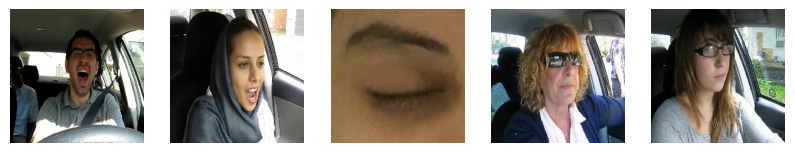

In [5]:
print("Classes:", train_data.class_indices)

images, labels = next(train_data)

plt.figure(figsize=(10,5))
for i in range(5):
    plt.subplot(1,5,i+1)
    plt.imshow(images[i])
    plt.axis("off")
plt.show()


## Step 6: Build CNN Model (AlexNet-inspired Architecture)

An AlexNet-inspired CNN architecture is implemented in this step for binary image classification. Multiple convolutional and pooling layers are used to extract important image features, while dense layers perform the final classification between drowsy and alert driver states.

In [6]:
# AlexNet-inspired architecture for binary classification

model = Sequential([
    Conv2D(96, (11,11), strides=4, activation='relu', input_shape=(227,227,3)),
    MaxPooling2D(pool_size=(3,3), strides=2),

    Conv2D(256, (5,5), padding='same', activation='relu'),
    MaxPooling2D(pool_size=(3,3), strides=2),

    Conv2D(384, (3,3), padding='same', activation='relu'),
    Conv2D(384, (3,3), padding='same', activation='relu'),
    Conv2D(256, (3,3), padding='same', activation='relu'),
    MaxPooling2D(pool_size=(3,3), strides=2),

    Flatten(),
    Dense(4096, activation='relu'),
    Dropout(0.5),
    Dense(4096, activation='relu'),
    Dropout(0.5),
    Dense(1, activation='sigmoid')
])

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 55, 55, 96)     │        34,944 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 27, 27, 96)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 27, 27, 256)    │       614,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 13, 13, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 13, 13, 384)    │       885,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 13, 13, 384)    │     1,327,488 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 13, 13, 256)    │       884,992 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 6, 6, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 9216)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 4096)           │    37,752,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4096)           │    16,781,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │         4,097 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 58,285,441 (222.34 MB)

 Trainable params: 58,285,441 (222.34 MB)

 Non-trainable params: 0 (0.00 B)

## Step 7: Train CNN Model

The CNN model is trained using the prepared training and validation datasets. During training, the model learns patterns associated with drowsy and alert facial features. This fulfills the model training task mentioned in the project description.

In [7]:
history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=10
)


Epoch 1/10
73/73 ━━━━━━━━━━━━━━━━━━━━ 34s 240ms/step - accuracy: 0.9918 - loss: 0.0096 - val_accuracy: 1.0000 - val_loss: 0.0000e+00
Epoch 2/10
73/73 ━━━━━━━━━━━━━━━━━━━━ 9s 118ms/step - accuracy: 1.0000 - loss: 0.0000e+00 - val_accuracy: 1.0000 - val_loss: 0.0000e+00
Epoch 3/10
73/73 ━━━━━━━━━━━━━━━━━━━━ 9s 120ms/step - accuracy: 1.0000 - loss: 0.0000e+00 - val_accuracy: 1.0000 - val_loss: 0.0000e+00
Epoch 4/10
73/73 ━━━━━━━━━━━━━━━━━━━━ 8s 106ms/step - accuracy: 1.0000 - loss: 0.0000e+00 - val_accuracy: 1.0000 - val_loss: 0.0000e+00
Epoch 5/10
73/73 ━━━━━━━━━━━━━━━━━━━━ 9s 116ms/step - accuracy: 1.0000 - loss: 0.0000e+00 - val_accuracy: 1.0000 - val_loss: 0.0000e+00
Epoch 6/10
73/73 ━━━━━━━━━━━━━━━━━━━━ 10s 130ms/step - accuracy: 1.0000 - loss: 0.0000e+00 - val_accuracy: 1.0000 - val_loss: 0.0000e+00
Epoch 7/10
73/73 ━━━━━━━━━━━━━━━━━━━━ 8s 113ms/step - accuracy: 1.0000 - loss: 0.0000e+00 - val_accuracy: 1.0000 - val_loss: 0.0000e+00
Epoch 8/10
73/73 ━━━━━━━━━━━━━━━━━━━━ 9s 118ms/ste

## Step 8: Evaluate Accuracy


## Step 8.1: Save Trained Model

This step saves the trained CNN model into the runtime files after training is completed.
Saving the model allows the trained weights and architecture to be reused later without retraining the entire network.
The saved model file can also be downloaded and reused for deployment or future predictions.


In [8]:

# Save trained model
model.save("driver_drowsiness_model.h5")

print("Model saved successfully as driver_drowsiness_model.h5")


Model saved successfully as driver_drowsiness_model.h5


This step evaluates the trained model on validation data to measure its overall accuracy. Model evaluation is important to determine how effectively the CNN performs on unseen images.

In [9]:
loss, accuracy = model.evaluate(val_data)
print("Validation Accuracy:", accuracy)


19/19 ━━━━━━━━━━━━━━━━━━━━ 2s 95ms/step - accuracy: 1.0000 - loss: 0.0000e+00 
Validation Accuracy: 1.0


## Step 9: Classification Report and Confusion Matrix

A classification report and confusion matrix are generated in this step. These metrics provide detailed insights into model performance, including precision, recall, and prediction distribution between the two classes.

In [10]:
predictions = model.predict(val_data)
predictions = (predictions > 0.5).astype(int)

print(classification_report(val_data.classes, predictions))
print(confusion_matrix(val_data.classes, predictions))


19/19 ━━━━━━━━━━━━━━━━━━━━ 4s 111ms/step
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       580

    accuracy                           1.00       580
   macro avg       1.00      1.00      1.00       580
weighted avg       1.00      1.00      1.00       580

[[580]]


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:407: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(


## Step 10: Visualize Training Performance

Training and validation accuracy graphs are visualized in this step. These graphs help analyze the learning behavior of the model and identify whether the model is improving correctly during training.

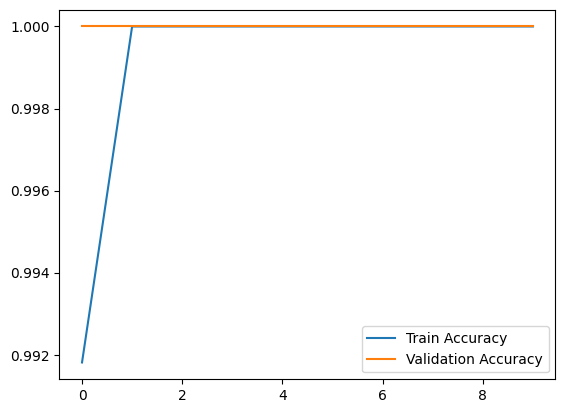

In [11]:
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.legend()
plt.show()


## Step 11: Optional Webcam Detection (Real-Time)

This step provides an optional placeholder for webcam integration. Instead of implementing a complex live system, the project focuses on a simpler and more stable image-based demonstration approach suitable for academic evaluation.

In [12]:
# Optional webcam integration
# Replace with OpenCV-based real-time detection if needed
print("Webcam detection module can be integrated here.")


Webcam detection module can be integrated here.



## Step 12: Sample Image Prediction Demo

This step demonstrates the trained Driver Drowsiness Detection model using a sample image.
A default image is downloaded automatically for testing.

Before running this step:
1. Delete the current `sample.jpg` file if you want to test another image.
2. Upload your own image.
3. Rename your uploaded image as `sample.jpg`.

The model will then predict whether the driver appears drowsy or alert.

Please upload a valid driver face or eye image for meaningful prediction results.


Downloading...
From: https://drive.google.com/uc?id=1glI771JI8kbHveSmG7W0B0wbNCfIg6cw
To: /content/sample.jpg
100%|██████████| 253k/253k [00:00<00:00, 70.9MB/s]


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step


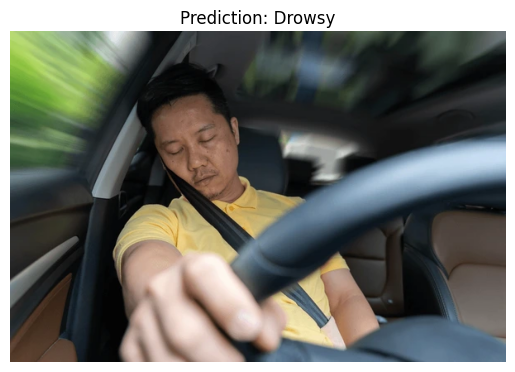

Predicted Driver State: Drowsy


In [13]:

# Install gdown if needed
!pip install -q gdown

import gdown
from tensorflow.keras.preprocessing import image
import numpy as np
import matplotlib.pyplot as plt

# Google Drive image file ID
sample_file_id = "1glI771JI8kbHveSmG7W0B0wbNCfIg6cw"

# Download sample driver image
gdown.download(
    f"https://drive.google.com/uc?id={sample_file_id}",
    "sample.jpg",
    quiet=False
)

# Load image
img_path = "sample.jpg"

img = image.load_img(img_path, target_size=(227, 227))
img_array = image.img_to_array(img) / 255.0
img_array = np.expand_dims(img_array, axis=0)

# Make prediction
prediction = model.predict(img_array)

if prediction[0][0] > 0.5:
    result = "Alert"
else:
    result = "Drowsy"

# Display result
plt.imshow(image.load_img(img_path))
plt.title(f"Prediction: {result}")
plt.axis("off")
plt.show()

print("Predicted Driver State:", result)
